In [1]:
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from spikeparam.patch.fit import Spike

/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


# Patch vs LFP Features

In [2]:
# Load data
lfp   = np.load('../datasets/lfp_filt.npy')
npx   = np.load('../datasets/npx_filt.npy')
patch = np.load('../datasets/patch_filt.npy')

fs_patch = 50023.88925263
fs_npx   = 30000
fs_lfp   = 2500

# Prevents edges issues by removing spikes withing .5s from start/end
patch[:int(fs_patch//2)] = 0
patch[-int(fs_patch//2):] = 0

In [3]:
# Custom LFP features to compare to patch features
def lfp_features(sig, fs):
    
    # Imports
    import numpy as np
    from neurodsp.spectral import compute_spectrum
    from fooof import FOOOF
    from statsmodels.tsa.ar_model import AutoReg
    
    # Spectral
    f, p = compute_spectrum(sig, fs, f_range=(0, 300), nperseg=200)
    
    fm = FOOOF(max_n_peaks=0, verbose=False)
    fm.fit(f, p)
    
    ap_params = fm.get_params('aperiodic')
    rsq = fm.r_squared_
    
    # Autoregressive
    ar = AutoReg(sig, 3)
    ar = ar.fit()
    ar0, ar1, ar2 = ar.params[1:]

    params = np.array([sig.mean(), sig.std(), *ap_params, rsq,
                       ar0, ar1, ar2])
    
    return params

In [4]:
# Initialize
sp = Spike(thresh_amp=200, window_length=(2, 5), smooth_frac=.1)

# Queue LFP features (+/- .25 seconds around patch peaks)
sp.alt(
    lfp, fs_lfp, lfp_features, ref='peak', window_length=(100.0, 100.0), queue=True,
    param_keys=[
        'lfp_mean', 'lfp_std', 'offset', 'exponent', 'rsq', 'ar0', 'ar1', 'ar2',
    ], n_jobs=-1, progress=tqdm
)

# Fit
sp.fit(patch, fs_patch, n_jobs=-1, progress=tqdm)

  0%|          | 0/5561 [00:00<?, ?it/s]

  0%|          | 0/5561 [00:00<?, ?it/s]

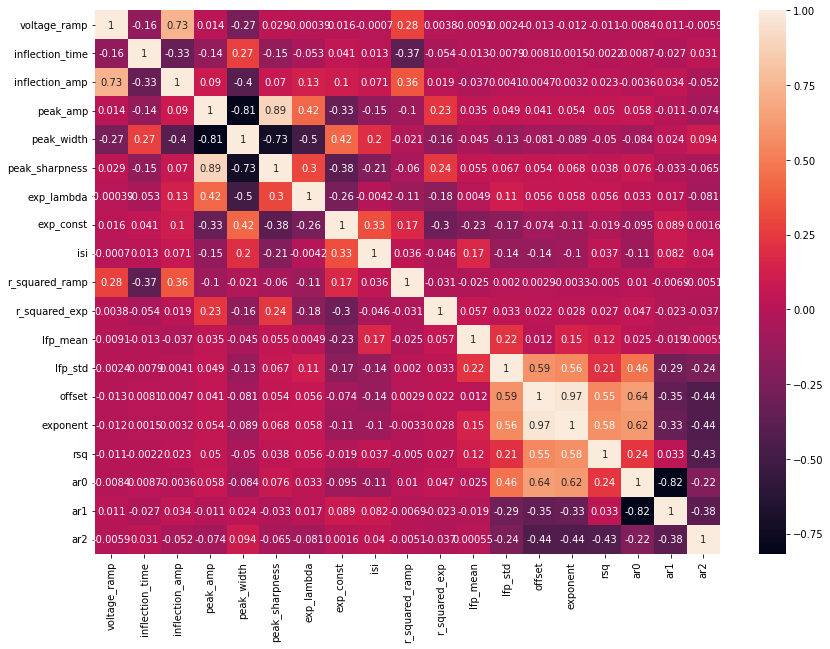

In [5]:
# Plot
fig, ax = plt.subplots(figsize=(14, 10))

spikes_corr = sp.df_features.corr()

sns.heatmap(spikes_corr, ax=ax, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)

plt.show()